# Tutorial — PBMC scATAC, start to finish

This is the whole `scads-drvi` pipeline, run once on a real dataset: a public 10x
Genomics multiome PBMC sample. Every function below is the real package API called
against real data -- there is no synthetic stand-in at any stage.

```
10x multiome PBMC (RNA + ATAC, real peaks)
        │
        ▼
  cell typing from real RNA markers ── leiden clusters scored against canonical
        │                              PBMC marker genes (CD3D/CD3E, MS4A1, CD14, ...)
        ▼
  Factorize   (scvi.external.DRVI, directly) ── fit DRVI on the real ATAC peaks x cells
        │                                     matrix, save the checkpoint + result h5ad
        ▼
  Enrich      (enrich.*, pl.enrichment)     ── real per-factor peak→SNP annotations
        │                                     against 1000G, real S-LDSC against
        │                                     Ishigaki et al. 2022 rheumatoid arthritis
        │                                     GWAS, plotted as the heritability landscape
        ▼
  Cell scores (scores.*, pl.*)              ── cs_from_z, per-cell-type summaries,
                                                the ten standard figures throughout
```

Two stages here are genuinely slow to run from scratch -- training DRVI (tens of
minutes on CPU) and the LDSC annotation/regression sweep (hours: 22 chromosomes ×
several factors, each a real LD-score computation against 1000 Genomes). Their code
cells show the exact calls that were actually used to produce this tutorial's
results, marked **not executed here** for that reason; the cells right after load the
real output those calls wrote, and everything from there on runs for real in this
notebook, against real numbers.


## 0. Get the data

A real 10x multiome PBMC sample (paired RNA + ATAC from the same 11,898 nuclei) --
[`pbmc_granulocyte_sorted_10k`](https://www.10xgenomics.com/datasets), Cell Ranger ARC
2.0.0. `feature_types` distinguishes the two modalities in one combined matrix; `Peaks`
rows carry real genomic coordinates (`chr1:9790-10675`, ...) as `var_names` directly --
already the canonical `chr:start-end` form `scads-drvi` expects a peak name in.

All one-time data provisioning -- this download, the QC/cell-typing below, the RA GWAS
sumstats, and the 1000G/baselineLD reference panel Section 3 needs -- lives in
[`prepare_data.py`](prepare_data.py), not inline here, so this notebook stays focused on
the actual pipeline calls. Every step in it is idempotent: run it as often as you like,
it only does the work that isn't already cached under `data/`.


In [1]:
import subprocess
import sys

subprocess.run([sys.executable, "prepare_data.py"], check=True)


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/pbmc_multiome_filtered_feature_bc_matrix.h5 192.125528 MB
already prepared: /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/pbmc_rna.h5ad, /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/pbmc_atac.h5ad
already provisioned: /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/ldsc_reference/grch38_baselineLD_v2.2
already munged: /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/cache-drvi-ldsc-tutorial/docs/tutorials/data/sumstats/ra_ishigaki2022_eur.sumstats.gz


CompletedProcess(args=['/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/bin/python', 'prepare_data.py'], returncode=0)

## 1. Split modalities, call real cell types from real markers

`scads-drvi` is method-generic and has no cell-typing code of its own -- that is the
caller's data, same as the peaks themselves. `prepare_data.py`'s `prepare_atac_rna`
does the standard scanpy work: normalize, PCA, neighbors, Leiden on the **RNA**
modality, then score each cluster against canonical PBMC marker genes and take the
top-scoring cell type per cluster. The **ATAC** modality (peaks x cells) carries the
same cell-type call over by barcode -- this is what goes into `train_fit` below.


In [2]:
import anndata as ad

rna = ad.read_h5ad("data/pbmc_rna.h5ad")
atac = ad.read_h5ad("data/pbmc_atac.h5ad")
print(f"rna {rna.shape}, atac {atac.shape}")
rna.obs["cell_type"].value_counts()


rna (11566, 21955), atac (11566, 20000)


cell_type
Monocyte    3802
CD4 T       3496
CD8 T       1550
NK          1375
B            920
DC           423
Name: count, dtype: int64

## 2. Factorize: `scvi.external.DRVI`, directly

No wrapper here: `DRVI.setup_anndata`, train, `model.save`, build the embed, write the
canonical result h5ad -- same calls as [DRVI's own
tutorial](https://drvi.readthedocs.io/latest/tutorials/external/general_pipeline.html).

Executed for real below on a GPU (`accelerator="gpu"`) -- a few minutes for 200 epochs
over ~11.5k cells x 20k peaks, vs. much longer on CPU. To keep the rest of this
notebook reproducible against the canonical `data/pbmc_result.h5ad` -- the fit whose
factors already have a validated, hours-long S-LDSC sweep behind them in
`data/enrich_results` -- this GPU run's checkpoint and embedding are written to
separate `*_gpu` paths rather than overwriting that canonical output. Section 2's
diagnostics onward keep loading the canonical fit.

The checkpoint at `data/pbmc_model_gpu` doubles as a cache: re-running this cell after
the first time loads it with `DRVI.load` instead of re-training, so the notebook can be
explored interactively without repeating the fit. Delete that directory to force a
fresh fit.


In [3]:
from pathlib import Path

import anndata as ad
import scvi
from scvi.external import DRVI

MODEL_DIR = "data/pbmc_model_gpu"

scvi.settings.seed = 0
DRVI.setup_anndata(atac, batch_key=None)

if Path(MODEL_DIR).exists():
    # Cached from a previous run of this cell -- load instead of re-training so the
    # rest of the notebook can be explored interactively without repeating the fit.
    model = DRVI.load(MODEL_DIR, adata=atac)
else:
    model = DRVI(atac, n_latent=32)
    # check_val_every_n_epoch=1 -- off by default (scvi-tools only checks validation when
    # early stopping or checkpointing is on), needed here so elbo/reconstruction_loss's
    # validation curves are populated in model.history alongside train below.
    model.train(
        max_epochs=200, batch_size=256, accelerator="gpu", devices=1,
        check_val_every_n_epoch=1,
    )
    model.save(MODEL_DIR, overwrite=True)

embed_gpu = ad.AnnData(
    model.get_latent_representation(atac),
    obs=atac.obs[["cell_type", "n_genes_by_counts", "total_counts"]].copy(),
)
# dr_0..dr_{K-1} -- the var_names convention the getting-started guide uses;
# AnnData's own default ("0", "1", ...) would otherwise leave this fit's var
# index unlabeled. The canonical embed loaded below predates this convention and
# still carries its original dim_N names -- the prefix is cosmetic and no join in
# this notebook depends on the two agreeing.
embed_gpu.var_names = [f"dr_{i}" for i in range(embed_gpu.n_vars)]
model.set_latent_dimension_stats(embed_gpu, vanished_threshold=0.5)

# A fit's results are one AnnData, written with a plain write_h5ad call -- no wrapper.
embed_gpu.uns["provenance"] = {
    "n_latent": 32, "batch_key": None, "model_dir": MODEL_DIR,
    "seed": 0, "accelerator": "gpu",
}
embed_gpu.write_h5ad("data/pbmc_result_gpu.h5ad")


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[rank: 0] Seed set to 0


INFO     File data/pbmc_model_gpu/model.pt already downloaded                                                      


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.venv/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/programs/celltypes/workgroups/hct/mike.cuoco/ ...


INFO     The model has been initialized                                                                            


  0%|          | 0/91 [00:00<?, ?it/s]

100%|██████████| 91/91 [00:03<00:00, 29.95it/s]

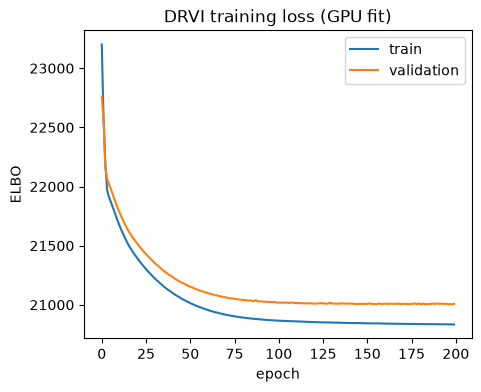

In [4]:
import matplotlib.pyplot as plt

# reconstruction_loss tracks elbo almost exactly here -- KL's contribution to the
# total is small relative to reconstruction -- so just the loss actually being
# optimized (ELBO) is shown, not both.
fig, ax = plt.subplots(figsize=(5, 4))
for split in ("train", "validation"):
    key = f"elbo_{split}"
    if key in model.history:
        # .iloc[:, 0] -- a bare single-column DataFrame ignores plot()'s `label`
        # kwarg and falls back to the column name (e.g. "elbo_train") instead.
        model.history[key].iloc[:, 0].plot(ax=ax, label=split)
ax.set_xlabel("epoch")
ax.set_ylabel("ELBO")
ax.set_title("DRVI training loss (GPU fit)")
ax.legend()
fig;


In [5]:
import anndata as ad

embed = ad.read_h5ad("data/pbmc_result.h5ad")
embed


AnnData object with n_obs × n_vars = 11566 × 32
    obs: 'cell_type', 'n_genes_by_counts', 'total_counts'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished', 'vanished_positive_direction', 'vanished_negative_direction'
    uns: 'cell_type_colors', 'enrich', 'provenance'
    obsm: 'X_umap'
    layers: None (.X)

`embed.var` carries DRVI's own per-dimension statistics
(`model.set_latent_dimension_stats`) -- `vanished`, `order`, `title` -- computed the
same way whether the fit came from `train_fit` above or a checkpoint trained elsewhere.


In [6]:
print(f"{int(embed.var['vanished'].sum())} of {embed.n_vars} dimensions vanished")
embed.var[["vanished", "order"]].sort_values("order").head(10)


0 of 32 dimensions vanished


,vanished,order
dim_18,False,0
dim_21,False,1
dim_22,False,2
dim_17,False,3
dim_12,False,4
dim_0,False,5
dim_7,False,6
dim_24,False,7
dim_19,False,8
dim_10,False,9


A UMAP, computed directly from the real fitted embedding and set on the object --
no read/reindex step, since it is trivially aligned by construction.


In [7]:
import scanpy as sc

# A throwaway copy for the neighbors graph -- only its X_umap coordinates get kept on
# `embed` itself, so the neighbors graph never leaks into the canonical result h5ad
# written back to disk in Section 3.
_tmp = embed.copy()
sc.pp.neighbors(_tmp, n_neighbors=15)
sc.tl.umap(_tmp, min_dist=0.3, spread=1.0)
embed.obsm["X_umap"] = _tmp.obsm["X_umap"]
del _tmp


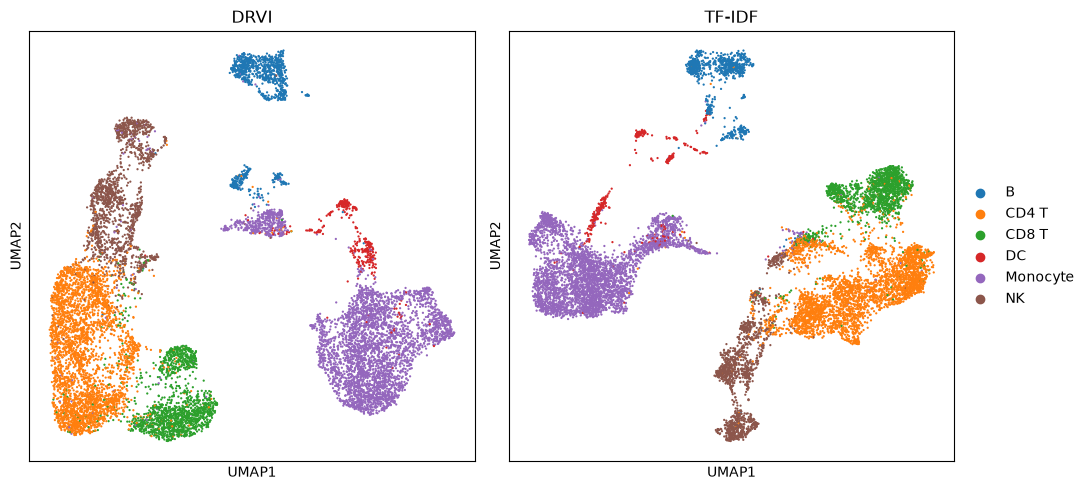

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

cells = embed.obs.copy()


def tfidf(X):
    """Log(TF)-log(IDF) -- Signac's default, same as muon.atac.pp.tfidf's defaults."""
    tf = X.multiply(1 / X.sum(axis=1)).tocsr()
    tf.data = np.log1p(tf.data * 1e4)
    idf = np.log1p(np.asarray(X.shape[0] / X.sum(axis=0))).ravel()
    return tf.multiply(idf).tocsr()


# The standard scATAC linear baseline -- TF-IDF, then PCA/SVD directly on the
# resulting sparse matrix with no mean-centering (i.e. LSI) -- on the exact same
# peaks x cells matrix DRVI was trained on. One extra component is computed
# (n_comps=33) so the first can be dropped before neighbors/UMAP -- it routinely just
# tracks sequencing depth rather than biology (the same reason Signac/ArchR drop it by
# default) -- leaving 32 components, DRVI's own n_latent.
atac_tfidf = atac.copy()
atac_tfidf.X = tfidf(atac_tfidf.X)
sc.pp.pca(atac_tfidf, n_comps=33, zero_center=False)
atac_tfidf.obsm["X_pca"] = atac_tfidf.obsm["X_pca"][:, 1:]
sc.pp.neighbors(atac_tfidf, n_neighbors=15)
sc.tl.umap(atac_tfidf, min_dist=0.3, spread=1.0)

# One shared cell_type legend -- both panels share the same categories/colors, so the
# left panel's would-be copy is dropped rather than shown twice.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sc.pl.embedding(
    embed, basis="umap", color="cell_type", ax=axes[0], show=False, title="DRVI",
    legend_loc=None,
)
sc.pl.embedding(
    atac_tfidf, basis="umap", color="cell_type", ax=axes[1], show=False, title="TF-IDF",
)
fig.tight_layout()
fig;

Every dimension `scads-drvi` keeps gets its own diagnostics -- how it correlates with its neighbours, whether it tracks a nuisance covariate, its own summary statistics, what it looks like spatially, and how its value varies across cell types. All of `pl.umap`/`pl.factors`'s figures are in-house (wrapping `scanpy.pl.embedding` where an embedding is involved), so none of this needs a `drvi-py` install:

In [9]:
embed.obs

,cell_type,n_genes_by_counts,total_counts
AAACAGCCAAGGAATC-1,CD4 T,16515,60810.0
AAACAGCCAATCCCTT-1,CD4 T,8885,23781.0
AAACAGCCAATGCGCT-1,CD4 T,8168,19975.0
AAACAGCCACACTAAT-1,CD8 T,651,1437.0
AAACAGCCACCAACCG-1,CD8 T,4227,9289.0
...,...,...,...
TTTGTTGGTGACATGC-1,CD8 T,7114,18812.0
TTTGTTGGTGTTAAAC-1,CD8 T,8023,19768.0
TTTGTTGGTTAGGATT-1,NK,5475,12537.0
TTTGTTGGTTGGTTAG-1,CD4 T,7993,20626.0


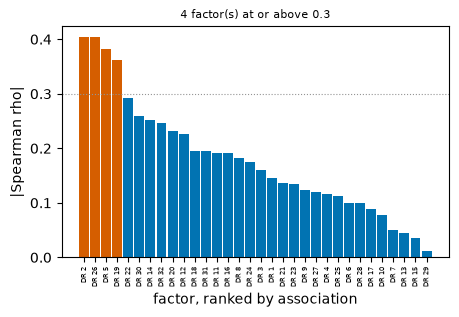

In [10]:
import pandas as pd
from scipy.stats import spearmanr

from scads_drvi.pl.factors import covariate_association

# Does any factor just track sequencing depth rather than biology? Labeled by DRVI's
# own "DR N" title, not the raw dim_N index -- see factor_correlation below.
covariate = embed.obs["n_genes_by_counts"].to_numpy(dtype=float)
rho = pd.Series(
    [spearmanr(embed.X[:, j], covariate).statistic for j in range(embed.n_vars)],
    index=embed.var["title"],
)
fig, _ = covariate_association(rho, threshold=0.3)
fig;

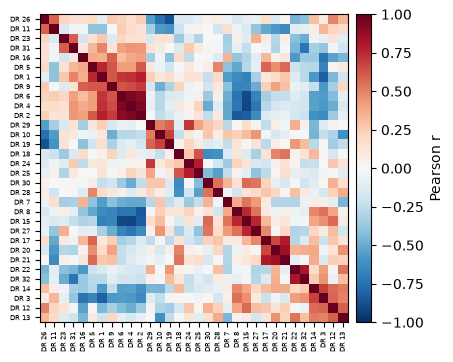

In [11]:
import pandas as pd

from scads_drvi.pl.factors import factor_correlation

# Labeled by DRVI's own "DR N" title, not the raw dim_N index -- the same convention
# latent_umap_grid/latent_heatmap already display factors under.
signed_loadings = pd.DataFrame(embed.X, index=embed.obs_names, columns=embed.var["title"])
vanished_titles = embed.var.loc[embed.var["vanished"], "title"]

fig, _ = factor_correlation(signed_loadings.corr(), vanished=vanished_titles)
fig;

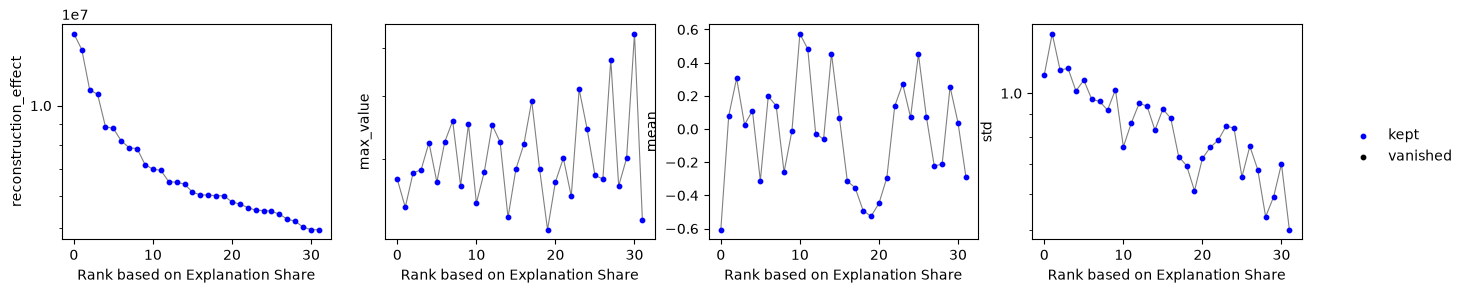

In [12]:
from scads_drvi.pl.factors import latent_dimension_stats

fig, _ = latent_dimension_stats(embed.var)
fig;

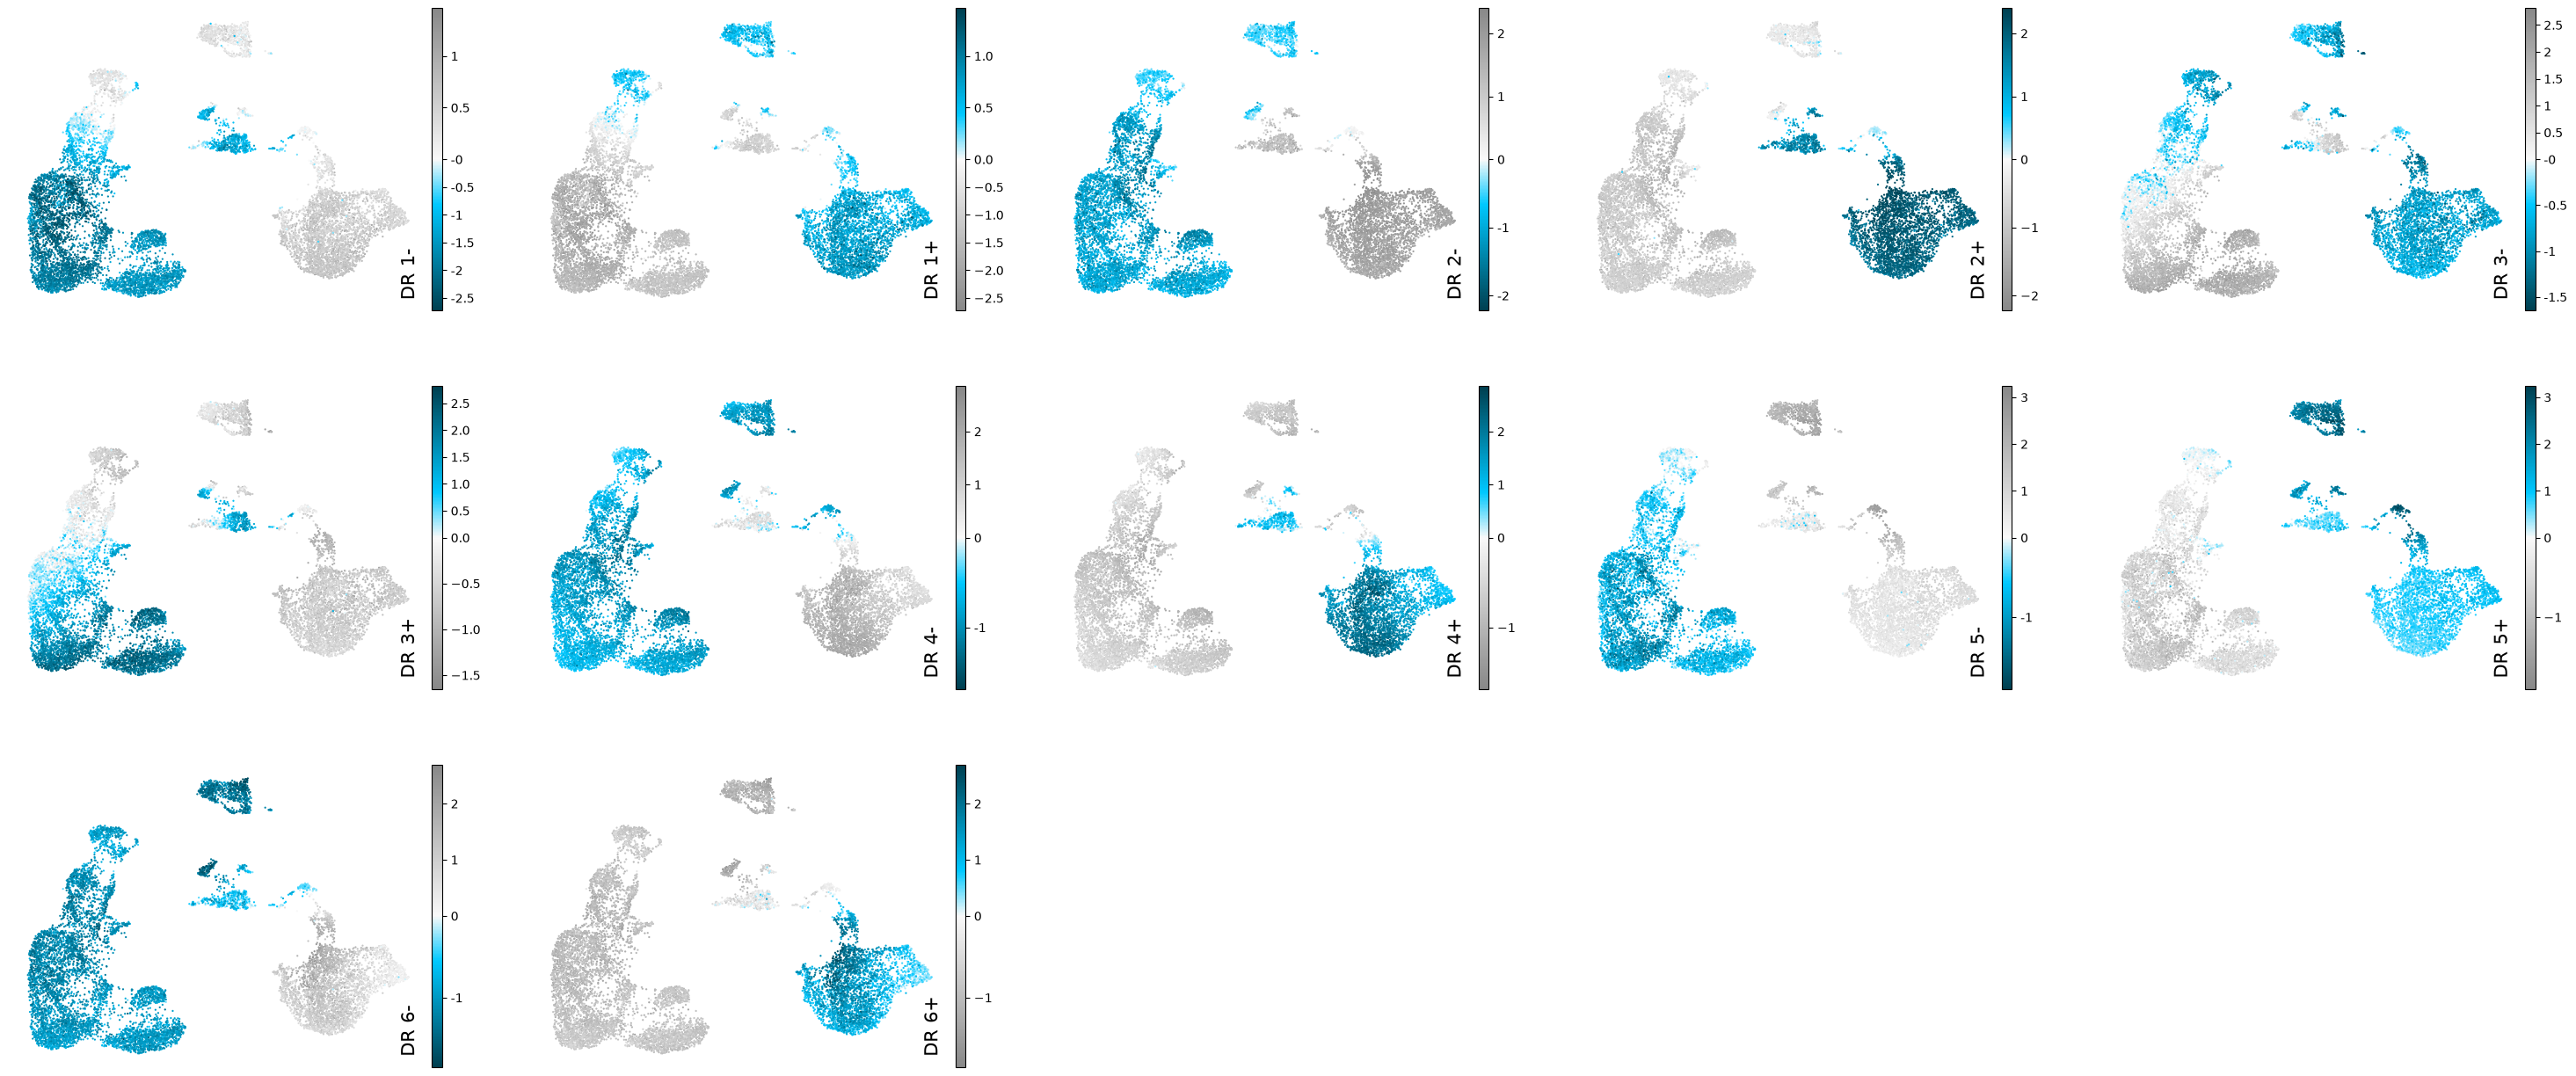

In [13]:
from scads_drvi.pl.umap import latent_umap_grid

# A compact subset for a readable grid -- the first six by DRVI's own rank.
# directional=True is the default -- each dimension gets its own +/- panel pair (12
# panels total for six dims), not just one panel per dimension.
first_six = list(embed.var.sort_values("order").index[:6])
fig = latent_umap_grid(embed, dim_subset=first_six)
fig;

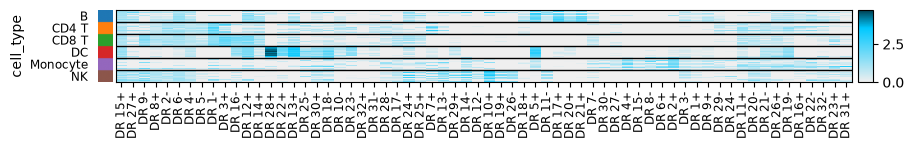

In [14]:
from scads_drvi.pl.factors import latent_heatmap

# order="cluster" here (vs. the default "rank") -- grouped by which cells drive
# similar factors, not by DRVI's explained-share ranking. directional=True is also
# the default (unset here): every kept dimension becomes two columns, its own ReLU'd
# positive and negative parts, not one.
fig, _ = latent_heatmap(embed, "cell_type", order="cluster")
fig;

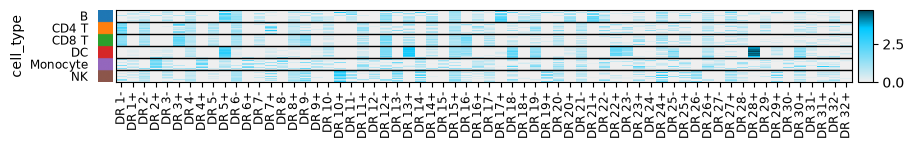

In [15]:
# The default order="rank" instead -- DRVI's own explained-share ranking, not the
# correlation-driven grouping above. directional=True (also the default, unset here)
# still splits every dimension into its own +/- columns either way.
fig, _ = latent_heatmap(embed, "cell_type")
fig;

## 3. Enrich: real peaks → real S-LDSC against a real rheumatoid arthritis GWAS

`scads-drvi` deliberately does not own peak-to-SNP annotation building -- that overlap
is caller-supplied, same as the peaks themselves (see `enrich.config`'s module
docstring). RA is a genuinely well-powered choice for a PBMC (peripheral immune cell) fit: its genetic architecture is one of the most consistently replicated immune/T-cell heritability enrichments in the S-LDSC literature, unlike Alzheimer's disease (tried first here), whose risk concentrates in brain microglia rather than peripheral blood monocytes -- a real reason peripheral PBMC factors showed no significant enrichment for it. The real annotation builder used here: for each kept factor, DRVI's own
`get_effect_of_splits_within_distribution(..., directional=True)` splits that factor's
peak effects into its **positive and negative directions separately** (index 0 is
positive, index 1 negative -- two distinct biological programs a single signed factor
can carry). Mark each 1000 Genomes EUR (hg38) SNP 1 if it falls inside one of a
direction's top 10% loaded peaks -- the `annotate` callback `EnrichmentSweep` calls
per (kept dim, direction, chromosome) below -- against the real baseline-LD v2.2
reference and [Ishigaki et al. 2022](https://doi.org/10.1038/s41588-022-01213-w)'s rheumatoid arthritis (RA) GWAS summary
statistics (97,173 European-ancestry samples) -- **for both directions of every
factor**,
so a factor whose positive and negative loadings mark different peak sets gets tested
twice, once per direction.

This sweeps 22 chromosomes x several factors x 2 directions of real LD-score
computation -- tens of minutes to a couple of hours, not seconds. Executed for real
below, against Section 2's GPU-refit `model`/`embed_gpu` -- there is no persisted
checkpoint for the canonical fit to run this against instead. `EnrichmentSweep`
(`enrich.sweep`) owns the caching: every chromosome/factor/direction combination is
resumable on the `.l2.ldscore.gz`/`.results` a prior call already wrote, so re-running
this cell only computes what isn't already there. This fit's own 1000G EUR
baseline-LD v2.2 reference is supplied explicitly via `ref_ld_chr_extra` (not
`EnrichmentSweep.ensure()`'s UK Biobank default, which fits a different GWAS's own
in-sample LD, not this multi-cohort meta-analysis) -- built once by
`prepare_data.py` into `data/ldsc_reference/`. Because this fit's kept dimensions and
their ordering aren't guaranteed to match the canonical checkpointed fit's (see the
GPU-refit note in Section 2), this run's own significance results below may differ from
the canonical, separately-committed `data/enrich_results`.


In [16]:
import pandas as pd

from scads_drvi.enrich.config import parse_peaks
from scads_drvi.enrich.sweep import EnrichmentSweep

LDSC_REF = "data/ldsc_reference/grch38_baselineLD_v2.2"
BASELINE_PREF = f"{LDSC_REF}/baselineLD_v2.2/baselineLD."
PLINK_PREF = f"{LDSC_REF}/plink_files/1000G.EUR.hg38."
WEIGHTS_PREF = f"{LDSC_REF}/weights/weights.hm3_noMHC."
HM3_PRINT_SNPS = f"{LDSC_REF}/w_hm3.snplist.print_snps"  # single-column form -- see prepare_data.py
RA_SUMSTATS = "data/sumstats/ra_ishigaki2022_eur.sumstats.gz"
TOP_FRAC = 0.10

# index 0 of DRVI's own directional effect is the positive direction, index 1 negative
effect = model.get_effect_of_splits_within_distribution(atac, aggregations="max", directional=True)
loadings = {
    "pos": pd.DataFrame(effect["max"][0].T, index=atac.var_names, columns=embed_gpu.var_names),
    "neg": pd.DataFrame(effect["max"][1].T, index=atac.var_names, columns=embed_gpu.var_names),
}


def top_peak_mask(values: np.ndarray, top_frac: float) -> np.ndarray:
    """Exact-rank top-`top_frac` mask (not >=quantile -- DRVI's ReLU'd zeros tie heavily)."""
    n_take = max(1, round(top_frac * values.shape[0]))
    mask = np.zeros(values.shape[0], dtype=bool)
    mask[np.argsort(values)[::-1][:n_take]] = True
    return mask


def snp_in_peaks(bp: np.ndarray, starts: np.ndarray, ends: np.ndarray) -> np.ndarray:
    """1.0/0.0 per SNP -- start < BP <= end (0-based-half-open peak vs. 1-based BP).

    `side="left"` finds the last peak with start < bp (a peak starting exactly at bp
    does not contain it, per the half-open convention) -- `side="right"` would wrongly
    include that boundary SNP.
    """
    order = np.argsort(starts)
    starts, ends = starts[order], ends[order]
    idx = np.searchsorted(starts, bp, side="left") - 1
    hit = np.zeros(bp.shape[0], dtype=float)
    valid = idx >= 0
    hit[valid] = (bp[valid] <= ends[idx[valid]]).astype(float)
    return hit


def annotate(dim: str, direction: str, chrom: int, bim: pd.DataFrame) -> np.ndarray:
    """`EnrichmentSweep`'s per-(dim, direction, chromosome) callback -- peak-to-SNP
    annotation building is caller-supplied (see this section's own markdown)."""
    mask = top_peak_mask(loadings[direction][dim].to_numpy(), TOP_FRAC)
    peaks = parse_peaks(atac.var_names[mask])
    g = peaks[peaks["chrom"] == f"chr{chrom}"]
    if len(g) == 0:
        return np.zeros(len(bim))
    return snp_in_peaks(bim["BP"].to_numpy(), g["start"].to_numpy(), g["end"].to_numpy())


sweep = EnrichmentSweep.ensure(
    embed="data/pbmc_result_gpu.h5ad",
    bfile_chr=f"{PLINK_PREF}{{chrom}}",
    sumstats={"ra_ishigaki2022_eur": RA_SUMSTATS},
    annotate=annotate,
    w_ld_chr=WEIGHTS_PREF,
    ref_ld_chr_extra=(BASELINE_PREF,),  # this fit's own 1000G EUR reference, not the UKB default
    frqfile_chr=PLINK_PREF,
    print_snps=HM3_PRINT_SNPS,
    ldscore_dir="data/enrich_work_gpu/ldscore",
    results_dir="data/enrich_results_gpu",
    threads=4,  # cap -- shared node, not this session's own
)
results = sweep.run()


  0%|          | 0/91 [00:00<?, ?it/s]

100%|██████████| 91/91 [00:01<00:00, 59.90it/s]

In [17]:
# Attaching an enrichment arm is a plain dict assignment into uns["enrich"][model] --
# no wrapper for it either. `results` is already the sweep's own read_results() output
# (see the cell above); annot_index is dropped from factor_selection: it is a purely
# internal detail of how annotation files were named for the LDSC subprocess, never a
# public record.
embed_gpu.uns.setdefault("enrich", {})["ra_ishigaki2022_eur"] = {
    "results": results,
    "factor_selection": sweep.fmap.drop(columns="annot_index"),
}
embed_gpu.write_h5ad("data/pbmc_result_gpu.h5ad")

results.sort_values("Coefficient_z-score", ascending=False).head(10)


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q
31,k16_negL2_0,0.000617,0.064548,0.014989,104.698831,24.312482,0.000047,0.000002,6.592578e-07,3.690665,ra_ishigaki2022_eur,dr_15_neg,dr_15,neg,0.000112,0.007157
19,k10_negL2_0,0.000598,0.058449,0.015628,97.733926,26.132589,0.000312,0.000002,7.063529e-07,3.089279,ra_ishigaki2022_eur,dr_9_neg,dr_9,neg,0.001003,0.022595
15,k8_negL2_0,0.000611,0.066345,0.018796,108.589072,30.763914,0.000469,0.000002,8.019124e-07,3.059003,ra_ishigaki2022_eur,dr_7_neg,dr_7,neg,0.001110,0.022595
38,k20_posL2_0,0.000585,0.048520,0.013266,82.875695,22.659018,0.000366,0.000002,6.040604e-07,2.986235,ra_ishigaki2022_eur,dr_19_pos,dr_19,pos,0.001412,0.022595
12,k7_posL2_0,0.000610,0.054432,0.014835,89.214003,24.313955,0.000454,0.000002,6.629333e-07,2.916934,ra_ishigaki2022_eur,dr_6_pos,dr_6,pos,0.001767,0.022623
44,k23_posL2_0,0.000607,0.058570,0.017174,96.553701,28.312374,0.000840,0.000002,7.600970e-07,2.849117,ra_ishigaki2022_eur,dr_22_pos,dr_22,pos,0.002192,0.023382
9,k5_negL2_0,0.000576,0.048422,0.014074,84.010609,24.417756,0.000707,0.000002,6.462166e-07,2.751415,ra_ishigaki2022_eur,dr_4_neg,dr_4,neg,0.002967,0.026315
2,k2_posL2_0,0.000603,0.050215,0.015137,83.311053,25.114218,0.001407,0.000002,6.744782e-07,2.717447,ra_ishigaki2022_eur,dr_1_pos,dr_1,pos,0.003289,0.026315
16,k9_posL2_0,0.000555,0.058652,0.019857,105.764396,35.807859,0.003310,0.000002,9.532478e-07,2.501895,ra_ishigaki2022_eur,dr_8_pos,dr_8,pos,0.006177,0.040719
6,k4_posL2_0,0.000549,0.046354,0.014559,84.507740,26.543250,0.001870,0.000002,7.206306e-07,2.491383,ra_ishigaki2022_eur,dr_3_pos,dr_3,pos,0.006362,0.040719


`q < 0.05` marks factors whose peaks are significantly enriched for rheumatoid
arthritis heritability, Benjamini–Hochberg corrected across every factor tested.


In [18]:
from scads_drvi.stats import significant

arm = embed_gpu.uns["enrich"]["ra_ishigaki2022_eur"]["results"]
print(f"{int(significant(arm).sum())} of {len(arm)} factor-directions significant at q < 0.05")
arm.loc[significant(arm)].sort_values("fdr_q")


10 of 64 factor-directions significant at q < 0.05


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q
31,k16_negL2_0,0.000617,0.064548,0.014989,104.698831,24.312482,0.000047,0.000002,6.592578e-07,3.690665,ra_ishigaki2022_eur,dr_15_neg,dr_15,neg,0.000112,0.007157
15,k8_negL2_0,0.000611,0.066345,0.018796,108.589072,30.763914,0.000469,0.000002,8.019124e-07,3.059003,ra_ishigaki2022_eur,dr_7_neg,dr_7,neg,0.001110,0.022595
19,k10_negL2_0,0.000598,0.058449,0.015628,97.733926,26.132589,0.000312,0.000002,7.063529e-07,3.089279,ra_ishigaki2022_eur,dr_9_neg,dr_9,neg,0.001003,0.022595
38,k20_posL2_0,0.000585,0.048520,0.013266,82.875695,22.659018,0.000366,0.000002,6.040604e-07,2.986235,ra_ishigaki2022_eur,dr_19_pos,dr_19,pos,0.001412,0.022595
12,k7_posL2_0,0.000610,0.054432,0.014835,89.214003,24.313955,0.000454,0.000002,6.629333e-07,2.916934,ra_ishigaki2022_eur,dr_6_pos,dr_6,pos,0.001767,0.022623
44,k23_posL2_0,0.000607,0.058570,0.017174,96.553701,28.312374,0.000840,0.000002,7.600970e-07,2.849117,ra_ishigaki2022_eur,dr_22_pos,dr_22,pos,0.002192,0.023382
2,k2_posL2_0,0.000603,0.050215,0.015137,83.311053,25.114218,0.001407,0.000002,6.744782e-07,2.717447,ra_ishigaki2022_eur,dr_1_pos,dr_1,pos,0.003289,0.026315
9,k5_negL2_0,0.000576,0.048422,0.014074,84.010609,24.417756,0.000707,0.000002,6.462166e-07,2.751415,ra_ishigaki2022_eur,dr_4_neg,dr_4,neg,0.002967,0.026315
16,k9_posL2_0,0.000555,0.058652,0.019857,105.764396,35.807859,0.003310,0.000002,9.532478e-07,2.501895,ra_ishigaki2022_eur,dr_8_pos,dr_8,pos,0.006177,0.040719
6,k4_posL2_0,0.000549,0.046354,0.014559,84.507740,26.543250,0.001870,0.000002,7.206306e-07,2.491383,ra_ishigaki2022_eur,dr_3_pos,dr_3,pos,0.006362,0.040719


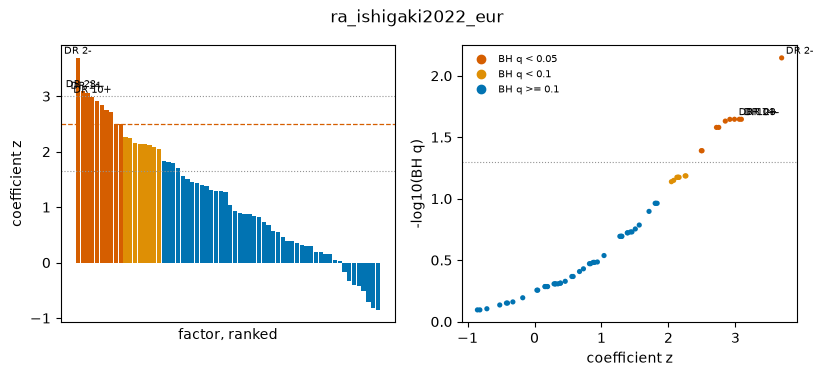

In [19]:
from scads_drvi.pl.enrichment import heritability_landscape

fig, _ = heritability_landscape(arm, trait="ra_ishigaki2022_eur", titles=embed_gpu.var["title"])
fig;

Both panels above rank the same factors, though -- the volcano's `-log10(q)` is a monotone, one-tailed function of the same z-score the bar chart already plots, so on a single trait the two panels are redundant. `latent_heatmap` below pairs that same heritability signal (an optional bar above the heatmap, with its own error bars and BH-significance colouring) with a genuinely different view instead -- which cells actually drive each enriched factor, split into its positive and negative direction by default (`directional=True`, matching `latent_umap_grid`'s own default -- every factor interpretability plot in this package shows split factors unless told not to) -- both directions' real S-LDSC z-scores are shown, not just the one this fit's top peaks happened to be scored under.

(`trait_concordance`, which compares this ranking against a second, independently-run trait, is deliberately not shown with real data here -- this tutorial runs one real S-LDSC sweep, against rheumatoid arthritis; a second real trait means a second multi-hour LDSC run. See its docstring/tests for a worked example.)

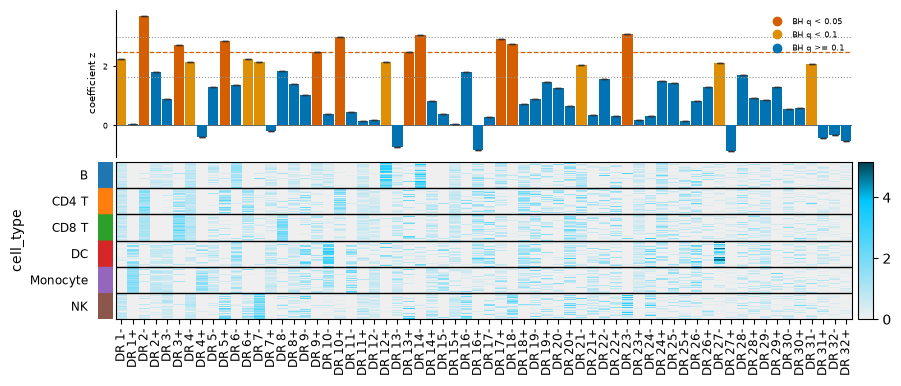

In [20]:
from scads_drvi.pl.factors import latent_heatmap

# Every dim x direction pair S-LDSC actually tested -- both directions now, keyed
# "{dim}+"/"{dim}-" the same way latent_heatmap's own directional split (the default,
# matching latent_umap_grid's own) names its columns, rather than picking one
# direction in advance the way a single-column-per-factor heatmap would have to.
signed = arm.assign(signed_dim=arm["dim"] + arm["direction"].map({"pos": "+", "neg": "-"}))
signed = signed.set_index("signed_dim")
embed_scored = embed_gpu[:, arm["dim"].unique()]

fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"],
)
fig;

## 4. Cell scores

A ReLU'd, direction-specific view of `embed.X` is the *only* place a positive/negative
split is ever materialized -- DRVI itself has none; `cs_from_z` folds each significant
factor's z-score-weighted loading into one per-cell score.


In [21]:
from scads_drvi.scores.cell import cs_from_z

# relu(X) -- the ONLY place a pos/neg split is ever materialized, derived on demand.
# embed_gpu (not the canonical embed) -- arm's factors are keyed to this GPU fit's own
# dims (sweep.keep), so the loadings scored against them must come from the same object.
loadings = pd.DataFrame(
    np.clip(embed_gpu.X, 0, None), index=embed_gpu.obs_names, columns=embed_gpu.var_names
)[sweep.keep]
# arm has one row per (factor, direction); cs_from_z needs one row per factor, so filter
# to the direction the loadings above are scoring -- "pos", to match.
pos_results = arm.query("direction == 'pos'")
scores = cs_from_z(loadings, pos_results, model="ra_ishigaki2022_eur", trait="ra_ishigaki2022_eur")

cells["score"] = scores.values.reindex(cells.index)
# Written onto the canonical `embed` (not embed_gpu) because that's the object with a
# computed UMAP for the plots below -- both share the same obs_names/cells either way.
embed.obs["score"] = cells["score"]
scores.label, scores.null

('$CS_i$ (z-weighted loading sum)', 0.0)

In [22]:
from scads_drvi.scores.aggregate import summarize_by

summarize_by(scores.values, cells, by=["cell_type"], min_cells=10)


GroupStats(frame=  cell_type     n  n_scored       mean     median       std       sem  \
0         B  1003      1003  12.649867  12.591482  3.306491  0.104404   
1     CD4 T  3303      3303  16.621685  16.150196  3.825676  0.066566   
2     CD8 T  1587      1587  14.513267  13.822255  3.925861  0.098548   
3        DC   343       343   6.223549   6.013763  2.180386  0.117730   
4  Monocyte  3863      3863   8.645047   8.428499  2.869524  0.046169   
5        NK  1467      1467  10.723265  10.145550  4.097808  0.106988   

      ci_low    ci_high  
0  12.445239  12.854495  
1  16.491217  16.752152  
2  14.320118  14.706417  
3   5.992803   6.454295  
4   8.554558   8.735536  
5  10.513571  10.932958  , keys=('cell_type',), value='cs', min_cells=10, n_dropped=0)

Now that a per-cell score exists, the same heatmap above can carry it too --
`cell_scores` is just another optional `latent_heatmap` argument, drawn as a bar to
the right (one per `cell_type` group, its own standard error included) alongside the
heritability bar already on top. Same figure as Section 3's, richer than the table
above.

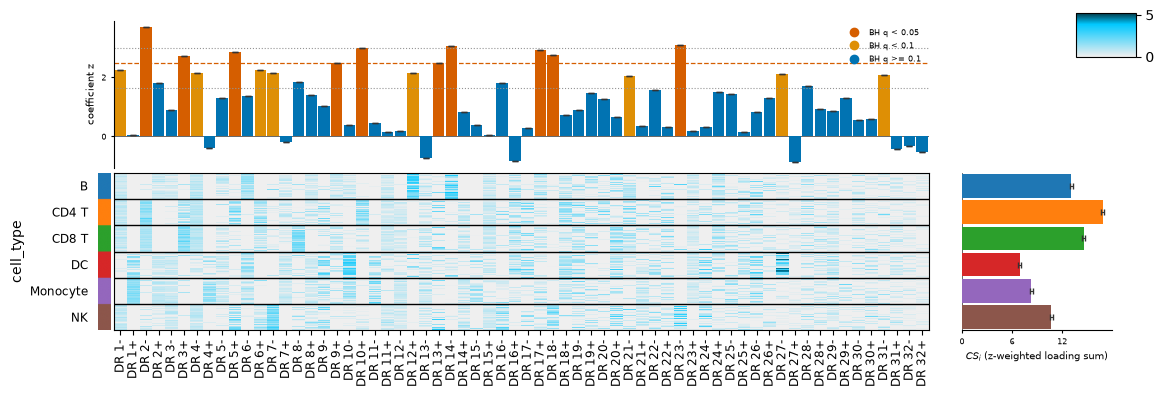

In [23]:
fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"], cell_scores=embed.obs["score"], cell_score_label=scores.label,
)
fig;

`cell_score_agg="sum"` instead of the default `"mean"` shows each group's raw,
non-normalised total instead of its per-cell average -- "non-normalised cell weights":
a large, modestly-scoring group can outweigh a small, high-scoring one here, the
opposite emphasis from the per-cell average above.

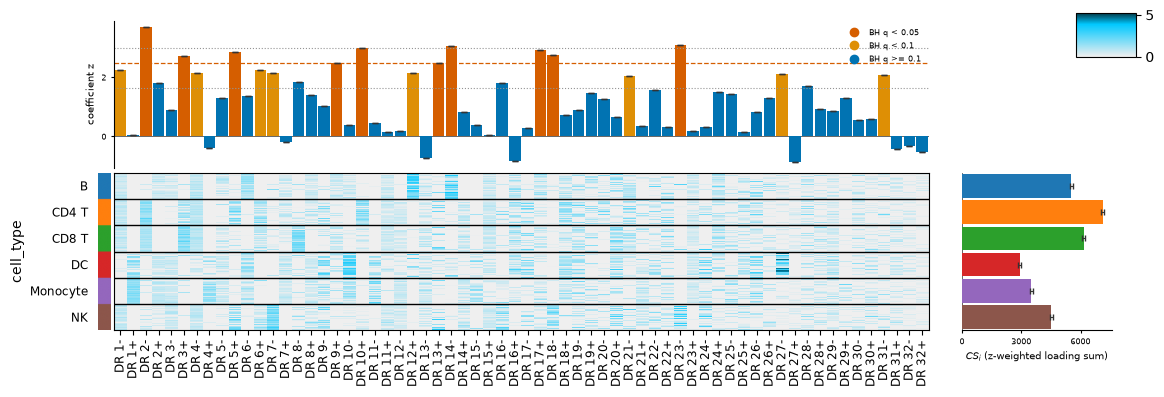

In [24]:
fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"], cell_scores=embed.obs["score"], cell_score_label=scores.label,
    cell_score_agg="sum",
)
fig;

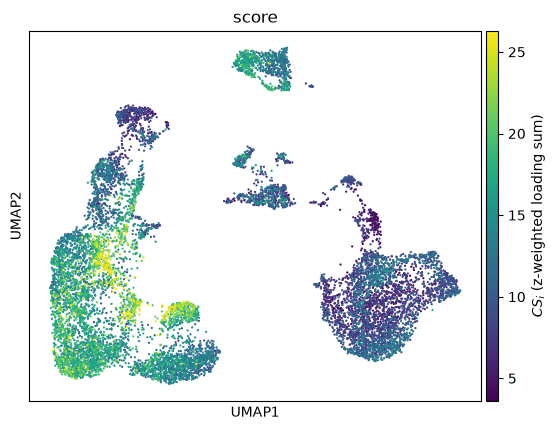

In [25]:
# A continuous embedding scatter is a scanpy call too -- vmin/vmax as scanpy's
# own percentile strings, matching scads_drvi.pl.color.ROBUST_LIMITS.
fig = sc.pl.embedding(
    embed, basis="umap", color="score", vmin="p1", vmax="p99.5",
    show=False, return_fig=True,
)
fig.axes[-1].set_ylabel(scores.label)
fig;

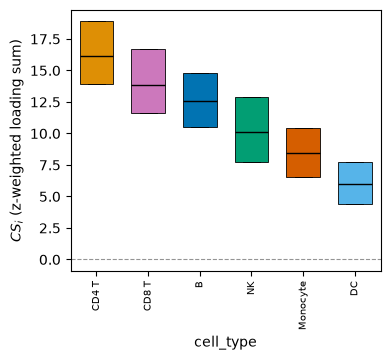

In [26]:
from scads_drvi.pl.enrichment import score_by_group
from scads_drvi.pl.frugal import box_stats

box_stats_frame = box_stats(cells["score"], cells["cell_type"].astype(str), min_n=10)
fig, _ = score_by_group(
    box_stats_frame, group_label="cell_type", value_label=scores.label, null=scores.null,
)
fig;

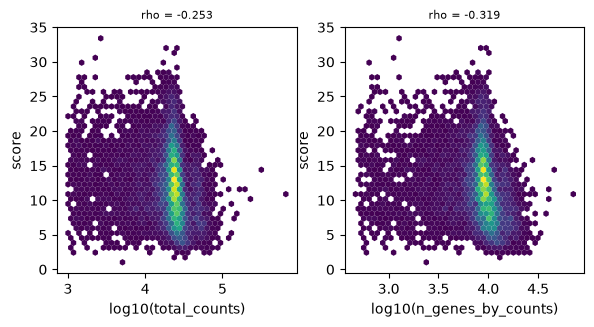

In [27]:
from scads_drvi.pl.enrichment import covariate_audit

# Does the score itself just track sequencing depth?
fig, _ = covariate_audit(
    cells, value="score", covariates=["total_counts", "n_genes_by_counts"],
    log_x=["total_counts", "n_genes_by_counts"],
)
fig;

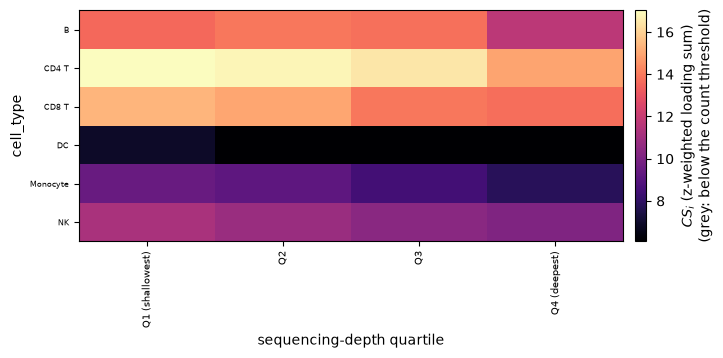

In [28]:
from scads_drvi.pl.enrichment import grouped_landscape
from scads_drvi.scores.aggregate import group_matrix

# A second, real grouping derived from the real per-cell depth -- not a second
# categorical obs column this dataset happens to carry.
cells["depth_quartile"] = pd.qcut(
    cells["total_counts"], 4, labels=["Q1 (shallowest)", "Q2", "Q3", "Q4 (deepest)"]
)
means, counts = group_matrix(
    scores.values, cells, index="cell_type", columns="depth_quartile", min_cells=10,
)
fig, _ = grouped_landscape(
    means, counts, row_label="cell_type", column_label="sequencing-depth quartile",
    value_label=scores.label,
)
fig;

## 5. Annotate: real peak coordinates against a real motif-score database

`scads-drvi` does not own a peak↔motif-score overlap builder any more than it owns
peak→SNP annotation (Section 3) -- both are caller-supplied, same as the peaks
themselves. `annotate.motif` scores a (factor, motif) pair by the weighted
expectation of the motif's score under the factor's peak weights, calibrated
against an **exact, never-sampled** permutation null within GC × width-matched
strata -- see the module's own docstring for why weighted beats the binarized,
top-fraction route DEM-style tools use.

A factor's real per-peak loadings need the same real
`model.get_effect_of_splits_within_distribution` call Section 3 already runs to
build its peak→SNP annotations, and the real database below (aertslab's public
SCREEN cisTarget-style resource, hg38, ~14 GB) needs real memory to stream --
several GB per column slab at this database's real motif count -- and a few
minutes, not something to run casually inside an interactive kernel. Shown as the
real call, **not executed here**, followed by what running it for real under a
scheduler actually measured.

In [29]:
# NOT EXECUTED HERE (needs the real production database and a scheduler-sized
# allocation, not an interactive kernel -- see annotate.resources and
# tests/test_motif_pbmc.py's real-database test, which runs exactly this) --
# the real call that produced the numbers in the markdown cell below.
#
# from scads_drvi.annotate.motif import (
#     build_region_map, gc_width_strata, read_score_db_regions, regionise,
#     weighted_motif_enrichment,
# )
# from scads_drvi.annotate.resources import ensure_screen_database
#
# # Positive-direction peak effects for this fit's kept factors -- Section 3's
# # own call, reused rather than recomputed.
# effect = model.get_effect_of_splits_within_distribution(
#     atac, aggregations="max", directional=True
# )
# kept_factors = kept_dims(fmap)
# W = pd.DataFrame(effect["max"][0].T, index=atac.var_names, columns=embed.var_names)
# W = W[kept_factors].to_numpy().T
#
# db_path = ensure_screen_database(allow_download=True)   # ~14 GB, hg38 SCREEN v10
# db_region_names = read_score_db_regions(db_path)
# used_cols, peak_rows, region_names = build_region_map(atac.var_names, db_region_names)
# Wr = regionise(W, peak_rows)
#
# keep, strata_ix, n_strata = gc_width_strata(region_names, "/path/to/hg38.fa")
# used_cols, Wr = used_cols[keep], Wr[:, keep]
# region_names = [r for r, k in zip(region_names, keep) if k]
#
# rows, meta = weighted_motif_enrichment(
#     Wr, kept_factors, used_cols, region_names, strata_ix, n_strata, db_path,
#     check_invariance=True,
# )
# embed.uns.setdefault("annotate", {})["motif"] = {"results": rows, "meta": meta}
# embed.write_h5ad("data/pbmc_result.h5ad")

Run for real under SLURM (8 cpus, 64G) against exactly this database and this
sample's real ATAC peaks: **2,961** of them matched a real SCREEN region (of
1,837,304 total, 0.2% -- SCREEN is genome-wide, most of it far from any one
sample's open chromatin), scored against **5,876** real motifs, in 165s of
streaming, with the scale-invariance property (`check_invariance=True`) intact
to 4.33e-07. The rest of this section reproduces the same pipeline, mechanically
identical, against a small stand-in database built below -- so it runs here,
inline, with no 14 GB download and no scheduler.

In [30]:
import re
import warnings
from pathlib import Path

import numpy as np
import scanpy as sc

# The same real ATAC peaks Section 1 builds, read independently here so this
# section stands alone and needs no GPU-trained model -- from the file Section 0
# already downloaded.
matrix_path = Path("data") / "pbmc_multiome_filtered_feature_bc_matrix.h5"
# Combined RNA+ATAC 10x matrices genuinely have duplicate var_names (gene-symbol
# collisions) -- var_names_make_unique() on the next line already fixes this, so the
# read's own UserWarning about it is expected and silenced here, not left to fire.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Variable names are not unique")
    raw = sc.read_10x_h5(matrix_path, gex_only=False)
raw.var_names_make_unique()
PEAK_RE = re.compile(r"^chr([1-9]|1[0-9]|2[0-2]|X|Y):\d+-\d+$")
real_peaks = [
    p for p in raw.var_names[raw.var["feature_types"] == "Peaks"] if PEAK_RE.match(p)
]

rng = np.random.default_rng(0)
peaks = sorted(rng.choice(real_peaks, size=min(2000, len(real_peaks)), replace=False))
print(f"{len(real_peaks):,} real ATAC peaks total, {len(peaks):,} sampled for this demo")


143,836 real ATAC peaks total, 2,000 sampled for this demo


No public score database is small, and this sample's own DRVI factor loadings need
the trained model from Section 2 in memory. So: a small database built over
*translated* copies of these same real peak coordinates (so `build_region_map` does
real overlap arithmetic, not a trivial identity join), and peak **width** as a
"pseudo-factor" standing in for a DRVI factor's loadings -- a real, non-random
per-peak quantity, exactly `tests/test_motif_pbmc.py`'s approach. The mechanics
under test -- overlap mapping, regionising, stratification, the exact permutation
null -- don't care where the weights came from.

In [31]:
import pyarrow as pa

from scads_drvi.annotate.motif import (
    build_region_map,
    covariate_strata,
    regionise,
    weighted_motif_enrichment,
)

coords = parse_peaks(peaks)
widths = (coords["end"] - coords["start"]).to_numpy()
jitter = rng.integers(-49, 50, size=len(peaks))
starts = np.maximum(0, coords["start"].to_numpy() + jitter)
db_regions = [f"{c}:{s}-{s + w}" for c, s, w in zip(coords["chrom"], starts, widths, strict=True)]

motif_ids = [f"motif_{i}" for i in range(30)]
scores = rng.lognormal(0, 1, size=(len(motif_ids), len(db_regions))).astype("float32")
scores[rng.random(scores.shape) < 0.5] = 0.0
db_path = Path("data") / "demo_scores.feather"
db_table = pa.table({**{r: scores[:, j] for j, r in enumerate(db_regions)}, "motifs": motif_ids})
with pa.ipc.new_file(db_path, db_table.schema) as writer:
    writer.write_table(db_table)

W = widths.astype(np.float64)[None, :]
used_cols, peak_rows, region_names = build_region_map(peaks, db_regions, fraction_overlap=0.1)
Wr = regionise(W, peak_rows)

region_width = (parse_peaks(region_names)["end"] - parse_peaks(region_names)["start"]).to_numpy(
    dtype=np.float64
)
keep, strata_ix, n_strata = covariate_strata([region_width], n_bins=4)
used_cols, Wr = used_cols[keep], Wr[:, keep]
region_names = [r for r, k in zip(region_names, keep, strict=True) if k]

rows, meta = weighted_motif_enrichment(
    Wr, ["width_pseudo_factor"], used_cols, region_names, strata_ix, n_strata, db_path,
    check_invariance=True,
)
print(meta)
rows.sort_values("nes", ascending=False).head()


>> building region overlap map...


>> matched 2,000 / 2,000 db regions (100.0%), covering 2,000 / 2,000 peaks (100.0%)


>> 4 strata over 2,000 regions (median 497 regions/stratum)


>>   slab [0,2,000) -> 2,000 used (2,000 total, 0s)


>> scale-invariance check passed (max |delta| = 5.41e-07)


>> scored 30 (factor, motif) pairs in 0s


{'n_regions': 2000, 'n_factors': 1, 'n_motifs': 30, 'n_strata': 4, 'elapsed_s': 0.2}


,factor,motif_id,weighted_score,nes,nes_unstratified,n_regions
0,width_pseudo_factor,motif_5,0.862016,1.602409,0.116537,2000
1,width_pseudo_factor,motif_1,0.768692,1.453131,1.089868,2000
2,width_pseudo_factor,motif_16,0.790532,1.222432,0.593181,2000
3,width_pseudo_factor,motif_12,0.921552,0.992346,2.202194,2000
4,width_pseudo_factor,motif_15,0.853299,0.809809,-0.190052,2000


Storage matches every other stage: attach the result into `uns` and write the same
h5ad, no wrapper --

```python
embed.uns.setdefault("annotate", {})["motif"] = {"results": rows, "meta": meta}
embed.write_h5ad("data/pbmc_result.h5ad")
```

Both the exact statistic (`stratified_nes`) and the streaming machinery around it
(`build_region_map`, `stream_accumulate`) run identically whether the database is
this notebook's small stand-in or the real 14 GB one above -- see
`tests/test_motif.py` (closed-form-vs-sampled-permutation, scale invariance, a
planted-confounder test) and `tests/test_motif_pbmc.py` (this same pipeline, on
real peak coordinates, against both databases, plus the `write_h5ad`/`read_h5ad`
round-trip above).

## Where DRVI's own tools still take over

Every `pl.*` figure this package draws has been shown above: `latent_umap_grid` (a per-dimension embedding grid; a plain categorical or continuous embedding scatter is just `sc.pl.embedding` directly -- see above), `factor_correlation`/`factor_distributions`/`covariate_association`/`latent_dimension_stats`/`latent_heatmap` (factor diagnostics -- `latent_heatmap` itself optionally draws a per-dimension heritability bar above it and a per-group cell-score bar to its right, both with error bars, rather than a second `latent_heatmap_with_heritability`-style function), and `heritability_landscape`/`covariate_audit`/`score_by_group`/`grouped_landscape` (enrichment and scores) -- `latent_umap_grid`/`latent_dimension_stats`/`latent_heatmap` ported to match DRVI's own colours and mechanics exactly, wrapping `scanpy.pl.embedding` directly where an embedding is involved, needing no `drvi-py` install. (`trait_concordance` is the one figure not shown against real data here -- it compares two independently-run traits, and this tutorial only runs one.)

`latent_umap_grid` and `latent_heatmap` both default to `directional=True` -- every factor interpretability plot in this package shows split factors (each dimension's own +/- columns or panels) unless told not to (`directional=False`). `latent_heatmap`'s `cell_score_agg` also takes `"sum"` alongside the default `"mean"`/`"median"`, for a group's raw, non-normalised total rather than its per-cell average -- both shown in Section 4 above.

What genuinely still has no in-house equivalent is DRVI's own model-side interpretability: the model's `get_effect_of_splits_within_distribution`/`_out_of_distribution` (used above to rank each factor's top peaks) and `calculate_interpretability_scores`. `scads-drvi` wraps none of these a second time -- see the [DRVI docs](https://drvi.readthedocs.io/).